# Rural Theater Reviews Analytics

The purpose of this project is to use natural language processing (NLP), sentiment analysis, topic modeling, and theme comparison to answer the question:


### What factors most influence customer satisfaction at rural performing arts venues?

#### Additional thinking questions:
- Are visitors discussing the performance itself or the broader tourism experience?
- What operational issues most affect customer ratings?
- Do tourists value different aspects of the experience than local patrons? <br>

#### Tools:
- Overall:
    - Python, pandas, numpy, matplotlib, seaborn
- Sentiment Analysis:
    - NLTK, Hugging Face, Scikit <br>
- Topic modeling
    - BERTopic

#### Data:
The dataset consists of 650+ publicly available reviews from five theaters in a rural, tourism-based locality. Web scraped using Google Sheets, Apify, and Make.com. While the findings may not generalize to large urban performing centers, they provide insight into customer experiences and satisfaction drivers within comparable rural arts organizations.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

df = pd.read_csv("Reviews Scraping - Data.csv")

df.head()

,Reviewer Name,Review Text,Published Date,Stars Given,Review URL,Owner Response Text,Venue name
0,Troy Everett,NaN,2026-02-02T17:58:49.434Z,5,https://www.google.com/maps/contrib/1007492457...,NaN,Door Shakespeare Day Time Office and Gift Shop
1,Zarata Tapsoba,Friendly staff❤️Great show !!❤️,2025-08-13T21:44:29.416Z,5,https://www.google.com/maps/contrib/1080433602...,NaN,Door Shakespeare Day Time Office and Gift Shop
2,Luther Snow,Best theater in Door County. Among the best S...,2025-08-08T21:54:25.906Z,5,https://www.google.com/maps/contrib/1150446054...,Hello Luther!\n\nThank you so much for your ki...,Door Shakespeare Day Time Office and Gift Shop
3,nancy mcgrath,Absolutely wonderful production! Our family me...,2025-07-29T04:33:19.793Z,5,https://www.google.com/maps/contrib/1037561463...,"Hello, Nancy!\n\nDelighted to hear that you an...",Door Shakespeare Day Time Office and Gift Shop
4,Jade D,My favorite part of Door County!!!! Absolutely...,2025-07-05T23:51:56.945Z,5,https://www.google.com/maps/contrib/1102217076...,"Thank you so much, Jade! We're thrilled to hea...",Door Shakespeare Day Time Office and Gift Shop


### Preproduction EDA

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 655 entries, 0 to 654
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Reviewer Name        655 non-null    str  
 1   Review Text          446 non-null    str  
 2   Published Date       655 non-null    str  
 3   Stars Given          655 non-null    int64
 4   Review URL           655 non-null    str  
 5   Owner Response Text  394 non-null    str  
 6   Venue name           655 non-null    str  
dtypes: int64(1), str(6)
memory usage: 35.9 KB


In [4]:
df.isnull().sum()

Reviewer Name            0
Review Text            209
Published Date           0
Stars Given              0
Review URL               0
Owner Response Text    261
Venue name               0
dtype: int64

Text(0.5, 0, 'Review Stars')

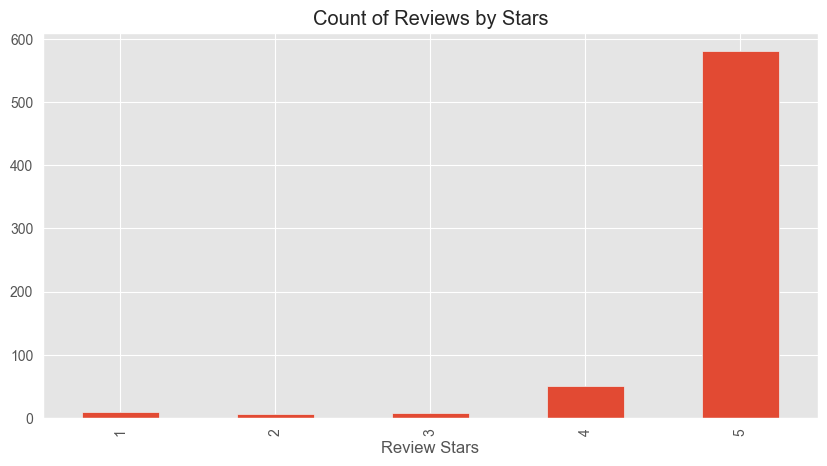

In [5]:
ax = (df['Stars Given'].value_counts().sort_index()
      .plot(kind='bar',
            title='Count of Reviews by Stars',
            figsize=(10,5)))
ax.set_xlabel('Review Stars')

In [6]:
percentages = df['Stars Given'].value_counts(normalize=True).sort_index() * 100
percentages

Stars Given
1     1.526718
2     0.916031
3     1.221374
4     7.786260
5    88.549618
Name: proportion, dtype: float64

Nearly 90% of the reviews are five stars, and over 95% are "positive" (4 or 5 stars). This shows a strong positive skew in the dataset, which has important implications for model evaluation. The extreme class imbalance means high overall accuracy is easily achieved, and performance in the minority negative and neutral classes will be a more meaningful indicator of model quality.

In [7]:
df['word_count'] = df['Review Text'].str.split().str.len()
df['word_count'].describe()

count    446.000000
mean      25.764574
std       32.217947
min        1.000000
25%        7.000000
50%       14.000000
75%       32.750000
max      308.000000
Name: word_count, dtype: float64

### Data Cleaning

In [8]:
# feature name normalization
df = df.rename(columns={
    "Reviewer Name": "reviewer_name",
    "Review Text": "review_text",
    "Published Date": "published_date",
    "Stars Given": "stars_given",
    "Review URL": "review_url",
    "Owner Response Text": "owner_response_text",
    "Venue name": "venue_name"
})

# use only reviews with text
df = df.dropna(subset=['review_text'])
df = df.drop_duplicates()
df = df[df['review_text'].str.strip() != ""]

# remove very short reviews
df = df[df['word_count'] >= 3]

df.shape

(420, 8)

In [9]:
import re
# create light cleaned text (for sentiment analysis) and full cleaned text (for topic modeling)
def light_clean_text(txt):
    """
    function that lightly cleans up text
    :param txt: uncleaned text
    :return: lightly cleaned text
    """
    txt = str(txt)
    txt = re.sub(r"http\S+", "", txt)
    txt = re.sub(r"\s+", " ", txt).strip()
    return txt

def full_clean_text(txt):
    """
    function that fully cleans up text
    :param txt: uncleaned text
    :return: fully cleaned text
    """
    txt = str(txt).lower()
    txt = re.sub(r"http\S+", "", txt)
    txt = re.sub(r"[^a-zA-Z\s]", "", txt)
    txt = re.sub(r"\s+", " ", txt).strip()
    return txt

df['light_clean_review'] = df['review_text'].apply(light_clean_text)
df['full_clean_review'] = df['review_text'].apply(full_clean_text)

# type conversion to datetime
df['published_date'] = pd.to_datetime(df['published_date']).dt.date

df = df.drop(columns=["reviewer_name"])

df.head()

,review_text,published_date,stars_given,review_url,owner_response_text,venue_name,word_count,light_clean_review,full_clean_review
1,Friendly staff❤️Great show !!❤️,2025-08-13,5,https://www.google.com/maps/contrib/1080433602...,NaN,Door Shakespeare Day Time Office and Gift Shop,4.0,Friendly staff❤️Great show !!❤️,friendly staffgreat show
2,Best theater in Door County. Among the best S...,2025-08-08,5,https://www.google.com/maps/contrib/1150446054...,Hello Luther!\n\nThank you so much for your ki...,Door Shakespeare Day Time Office and Gift Shop,64.0,Best theater in Door County. Among the best Sh...,best theater in door county among the best sha...
3,Absolutely wonderful production! Our family me...,2025-07-29,5,https://www.google.com/maps/contrib/1037561463...,"Hello, Nancy!\n\nDelighted to hear that you an...",Door Shakespeare Day Time Office and Gift Shop,45.0,Absolutely wonderful production! Our family me...,absolutely wonderful production our family mem...
4,My favorite part of Door County!!!! Absolutely...,2025-07-05,5,https://www.google.com/maps/contrib/1102217076...,"Thank you so much, Jade! We're thrilled to hea...",Door Shakespeare Day Time Office and Gift Shop,21.0,My favorite part of Door County!!!! Absolutely...,my favorite part of door county absolutely ama...
6,"Recently, attended the Shakespeare play “As yo...",2023-08-16,3,https://www.google.com/maps/contrib/1024878977...,NaN,Door Shakespeare Day Time Office and Gift Shop,47.0,"Recently, attended the Shakespeare play “As yo...",recently attended the shakespeare play as you ...


### NLTK: VADERS Baseline Sentiment Analysis

In [10]:
from nltk.sentiment import SentimentIntensityAnalyzer
from tqdm.notebook import tqdm

sia = SentimentIntensityAnalyzer()

In [11]:
res = {}
for i, row in tqdm(df.iterrows(), total=len(df)):
    text = row['light_clean_review']
    res[i] = sia.polarity_scores(text)


vaders = pd.DataFrame(res).T
vaders = vaders.merge(df, left_index=True, right_index=True, how='left')
vaders = vaders.rename(columns={'neg' : 'vaders_neg', 'neu' : 'vaders_neu', 'pos' : 'vaders_pos', 'compound' : 'vaders_compound'})
vaders.head()

  0%|          | 0/420 [00:00<?, ?it/s]

,vaders_neg,vaders_neu,vaders_pos,vaders_compound,review_text,published_date,stars_given,review_url,owner_response_text,venue_name,word_count,light_clean_review,full_clean_review
1,0.000,0.442,0.558,0.5837,Friendly staff❤️Great show !!❤️,2025-08-13,5,https://www.google.com/maps/contrib/1080433602...,NaN,Door Shakespeare Day Time Office and Gift Shop,4.0,Friendly staff❤️Great show !!❤️,friendly staffgreat show
2,0.000,0.616,0.384,0.9862,Best theater in Door County. Among the best S...,2025-08-08,5,https://www.google.com/maps/contrib/1150446054...,Hello Luther!\n\nThank you so much for your ki...,Door Shakespeare Day Time Office and Gift Shop,64.0,Best theater in Door County. Among the best Sh...,best theater in door county among the best sha...
3,0.000,0.698,0.302,0.9540,Absolutely wonderful production! Our family me...,2025-07-29,5,https://www.google.com/maps/contrib/1037561463...,"Hello, Nancy!\n\nDelighted to hear that you an...",Door Shakespeare Day Time Office and Gift Shop,45.0,Absolutely wonderful production! Our family me...,absolutely wonderful production our family mem...
4,0.000,0.685,0.315,0.8504,My favorite part of Door County!!!! Absolutely...,2025-07-05,5,https://www.google.com/maps/contrib/1102217076...,"Thank you so much, Jade! We're thrilled to hea...",Door Shakespeare Day Time Office and Gift Shop,21.0,My favorite part of Door County!!!! Absolutely...,my favorite part of door county absolutely ama...
6,0.119,0.692,0.189,0.2144,"Recently, attended the Shakespeare play “As yo...",2023-08-16,3,https://www.google.com/maps/contrib/1024878977...,NaN,Door Shakespeare Day Time Office and Gift Shop,47.0,"Recently, attended the Shakespeare play “As yo...",recently attended the shakespeare play as you ...


### HuggingFace's Roberta Model (Pretrained Transformer model)

In [12]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from scipy.special import softmax

example = df.iloc[150]['light_clean_review']
print(sia.polarity_scores(example))
print(example)

{'neg': 0.0, 'neu': 0.496, 'pos': 0.504, 'compound': 0.9458}
Wow. What a special place with special people and a special performance! A visit to Door County will never be complete without a show. Wow!


In [13]:
roberta_MODEL = "cardiffnlp/twitter-roberta-base-sentiment"
roberta_tokenizer = AutoTokenizer.from_pretrained(roberta_MODEL)
roberta_model = AutoModelForSequenceClassification.from_pretrained(roberta_MODEL)

encoded_text = roberta_tokenizer(example, return_tensors='pt')
output = roberta_model(**encoded_text)
scores = output.logits[0].detach().numpy()
scores = softmax(scores)

scores_dict = {
    'roberta_neg' : scores[0],
    'roberta_neu' : scores[1],
    'roberta_pos' : scores[2]
}

scores_dict = {
    k: round(float(v), 3)
    for k, v in scores_dict.items()
}

print(scores_dict)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

{'roberta_neg': 0.002, 'roberta_neu': 0.011, 'roberta_pos': 0.988}


In [14]:
def polarity_scores_roberta(txt):
    """
    function that scores input text on sentiment analysis based on pretrained roberta model
    :param txt: input text
    :return: a dictionary of negative, neutral, and positive scores
    """
    encoded_txt = roberta_tokenizer(txt, return_tensors='pt')
    txt_output = roberta_model(**encoded_txt)
    txt_scores = txt_output.logits[0].detach().numpy()
    txt_scores = softmax(txt_scores)
    txt_scores_dict = {
        'roberta_neg' : txt_scores[0],
        'roberta_neu' : txt_scores[1],
        'roberta_pos' : txt_scores[2]
    }
    return txt_scores_dict


res2 = {}
for i, row in tqdm(df.iterrows(), total=len(df)):
    text = row['light_clean_review']
    res2[i] = polarity_scores_roberta(text)


roberta = pd.DataFrame(res2).T
roberta = roberta.merge(df, left_index=True, right_index=True, how='left')
roberta['roberta_compound'] = roberta['roberta_pos'] - roberta['roberta_neg']
roberta.head()

  0%|          | 0/420 [00:00<?, ?it/s]

,roberta_neg,roberta_neu,roberta_pos,review_text,published_date,stars_given,review_url,owner_response_text,venue_name,word_count,light_clean_review,full_clean_review,roberta_compound
1,0.001475,0.008463,0.990062,Friendly staff❤️Great show !!❤️,2025-08-13,5,https://www.google.com/maps/contrib/1080433602...,NaN,Door Shakespeare Day Time Office and Gift Shop,4.0,Friendly staff❤️Great show !!❤️,friendly staffgreat show,0.988587
2,0.001849,0.013335,0.984815,Best theater in Door County. Among the best S...,2025-08-08,5,https://www.google.com/maps/contrib/1150446054...,Hello Luther!\n\nThank you so much for your ki...,Door Shakespeare Day Time Office and Gift Shop,64.0,Best theater in Door County. Among the best Sh...,best theater in door county among the best sha...,0.982966
3,0.001277,0.007027,0.991696,Absolutely wonderful production! Our family me...,2025-07-29,5,https://www.google.com/maps/contrib/1037561463...,"Hello, Nancy!\n\nDelighted to hear that you an...",Door Shakespeare Day Time Office and Gift Shop,45.0,Absolutely wonderful production! Our family me...,absolutely wonderful production our family mem...,0.990419
4,0.002348,0.006077,0.991575,My favorite part of Door County!!!! Absolutely...,2025-07-05,5,https://www.google.com/maps/contrib/1102217076...,"Thank you so much, Jade! We're thrilled to hea...",Door Shakespeare Day Time Office and Gift Shop,21.0,My favorite part of Door County!!!! Absolutely...,my favorite part of door county absolutely ama...,0.989227
6,0.400849,0.337175,0.261975,"Recently, attended the Shakespeare play “As yo...",2023-08-16,3,https://www.google.com/maps/contrib/1024878977...,NaN,Door Shakespeare Day Time Office and Gift Shop,47.0,"Recently, attended the Shakespeare play “As yo...",recently attended the shakespeare play as you ...,-0.138874


In [15]:
sentiment_df = df.copy()

sentiment_df = sentiment_df.merge(
    vaders[["vaders_neg", "vaders_neu", "vaders_pos", "vaders_compound"]],
    left_index=True,
    right_index=True,
    how="left"
)

sentiment_df = sentiment_df.merge(
    roberta[["roberta_neg", "roberta_neu", "roberta_pos", "roberta_compound"]],
    left_index=True,
    right_index=True,
    how="left"
)

sentiment_df.head()

,review_text,published_date,stars_given,review_url,owner_response_text,venue_name,word_count,light_clean_review,full_clean_review,vaders_neg,vaders_neu,vaders_pos,vaders_compound,roberta_neg,roberta_neu,roberta_pos,roberta_compound
1,Friendly staff❤️Great show !!❤️,2025-08-13,5,https://www.google.com/maps/contrib/1080433602...,NaN,Door Shakespeare Day Time Office and Gift Shop,4.0,Friendly staff❤️Great show !!❤️,friendly staffgreat show,0.000,0.442,0.558,0.5837,0.001475,0.008463,0.990062,0.988587
2,Best theater in Door County. Among the best S...,2025-08-08,5,https://www.google.com/maps/contrib/1150446054...,Hello Luther!\n\nThank you so much for your ki...,Door Shakespeare Day Time Office and Gift Shop,64.0,Best theater in Door County. Among the best Sh...,best theater in door county among the best sha...,0.000,0.616,0.384,0.9862,0.001849,0.013335,0.984815,0.982966
3,Absolutely wonderful production! Our family me...,2025-07-29,5,https://www.google.com/maps/contrib/1037561463...,"Hello, Nancy!\n\nDelighted to hear that you an...",Door Shakespeare Day Time Office and Gift Shop,45.0,Absolutely wonderful production! Our family me...,absolutely wonderful production our family mem...,0.000,0.698,0.302,0.9540,0.001277,0.007027,0.991696,0.990419
4,My favorite part of Door County!!!! Absolutely...,2025-07-05,5,https://www.google.com/maps/contrib/1102217076...,"Thank you so much, Jade! We're thrilled to hea...",Door Shakespeare Day Time Office and Gift Shop,21.0,My favorite part of Door County!!!! Absolutely...,my favorite part of door county absolutely ama...,0.000,0.685,0.315,0.8504,0.002348,0.006077,0.991575,0.989227
6,"Recently, attended the Shakespeare play “As yo...",2023-08-16,3,https://www.google.com/maps/contrib/1024878977...,NaN,Door Shakespeare Day Time Office and Gift Shop,47.0,"Recently, attended the Shakespeare play “As yo...",recently attended the shakespeare play as you ...,0.119,0.692,0.189,0.2144,0.400849,0.337175,0.261975,-0.138874


### Sentiment Analysis Evaluation

In [16]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score

def label_from_stars(stars):
    """
    function that labels sentiment as positive, neutral, or negative, based on the number of stars given in a rating
    :param stars: star rating
    :return: sentiment label
    """
    if stars >= 4:
        return 'positive'
    elif stars == 3:
        return 'neutral'
    else:
        return 'negative'

sentiment_df['true_label'] = sentiment_df['stars_given'].apply(label_from_stars)

def label_from_compound(score):
    if score >= 0.1:
        return 'positive'
    if score <= -0.1:
        return 'negative'
    else:
        return 'neutral'

sentiment_df['vaders_label'] = sentiment_df['vaders_compound'].apply(label_from_compound)
sentiment_df['roberta_label'] = sentiment_df['roberta_compound'].apply(label_from_compound)

sentiment_df.head()

,review_text,published_date,stars_given,review_url,owner_response_text,venue_name,word_count,light_clean_review,full_clean_review,vaders_neg,vaders_neu,vaders_pos,vaders_compound,roberta_neg,roberta_neu,roberta_pos,roberta_compound,true_label,vaders_label,roberta_label
1,Friendly staff❤️Great show !!❤️,2025-08-13,5,https://www.google.com/maps/contrib/1080433602...,NaN,Door Shakespeare Day Time Office and Gift Shop,4.0,Friendly staff❤️Great show !!❤️,friendly staffgreat show,0.000,0.442,0.558,0.5837,0.001475,0.008463,0.990062,0.988587,positive,positive,positive
2,Best theater in Door County. Among the best S...,2025-08-08,5,https://www.google.com/maps/contrib/1150446054...,Hello Luther!\n\nThank you so much for your ki...,Door Shakespeare Day Time Office and Gift Shop,64.0,Best theater in Door County. Among the best Sh...,best theater in door county among the best sha...,0.000,0.616,0.384,0.9862,0.001849,0.013335,0.984815,0.982966,positive,positive,positive
3,Absolutely wonderful production! Our family me...,2025-07-29,5,https://www.google.com/maps/contrib/1037561463...,"Hello, Nancy!\n\nDelighted to hear that you an...",Door Shakespeare Day Time Office and Gift Shop,45.0,Absolutely wonderful production! Our family me...,absolutely wonderful production our family mem...,0.000,0.698,0.302,0.9540,0.001277,0.007027,0.991696,0.990419,positive,positive,positive
4,My favorite part of Door County!!!! Absolutely...,2025-07-05,5,https://www.google.com/maps/contrib/1102217076...,"Thank you so much, Jade! We're thrilled to hea...",Door Shakespeare Day Time Office and Gift Shop,21.0,My favorite part of Door County!!!! Absolutely...,my favorite part of door county absolutely ama...,0.000,0.685,0.315,0.8504,0.002348,0.006077,0.991575,0.989227,positive,positive,positive
6,"Recently, attended the Shakespeare play “As yo...",2023-08-16,3,https://www.google.com/maps/contrib/1024878977...,NaN,Door Shakespeare Day Time Office and Gift Shop,47.0,"Recently, attended the Shakespeare play “As yo...",recently attended the shakespeare play as you ...,0.119,0.692,0.189,0.2144,0.400849,0.337175,0.261975,-0.138874,neutral,positive,negative


In [17]:
labels = ['negative', 'neutral', 'positive']

print("VADERS classification report")
print(classification_report(
    sentiment_df['true_label'],
    sentiment_df['vaders_label'],
    labels=labels,
    zero_division=0
))
print("\n")
print("RoBERTa classification report")
print(classification_report(
    sentiment_df['true_label'],
    sentiment_df['roberta_label'],
    labels=labels,
    zero_division=0
))

print("VADER predicted distribution:")
print(sentiment_df['vaders_label'].value_counts())

print("\nRoBERTa predicted distribution:")
print(sentiment_df['roberta_label'].value_counts())

print("\nTrue label distribution:")
print(sentiment_df['true_label'].value_counts())

VADERS classification report
              precision    recall  f1-score   support

    negative       0.69      0.56      0.62        16
     neutral       0.00      0.00      0.00         5
    positive       0.98      0.97      0.97       399

    accuracy                           0.94       420
   macro avg       0.56      0.51      0.53       420
weighted avg       0.95      0.94      0.95       420



RoBERTa classification report
              precision    recall  f1-score   support

    negative       0.59      0.81      0.68        16
     neutral       0.00      0.00      0.00         5
    positive       0.99      0.98      0.98       399

    accuracy                           0.96       420
   macro avg       0.53      0.60      0.56       420
weighted avg       0.96      0.96      0.96       420

VADER predicted distribution:
vaders_label
positive    396
negative     13
neutral      11
Name: count, dtype: int64

RoBERTa predicted distribution:
roberta_label
positive    3

VADER Binary Report
              precision    recall  f1-score   support

    negative       0.75      0.56      0.64        16
    positive       0.99      0.97      0.98       399

   micro avg       0.98      0.95      0.97       415
   macro avg       0.87      0.77      0.81       415
weighted avg       0.98      0.95      0.97       415

RoBERTa Binary Report
              precision    recall  f1-score   support

    negative       0.65      0.81      0.72        16
    positive       0.99      0.98      0.99       399

   micro avg       0.98      0.98      0.98       415
   macro avg       0.82      0.90      0.86       415
weighted avg       0.98      0.98      0.98       415



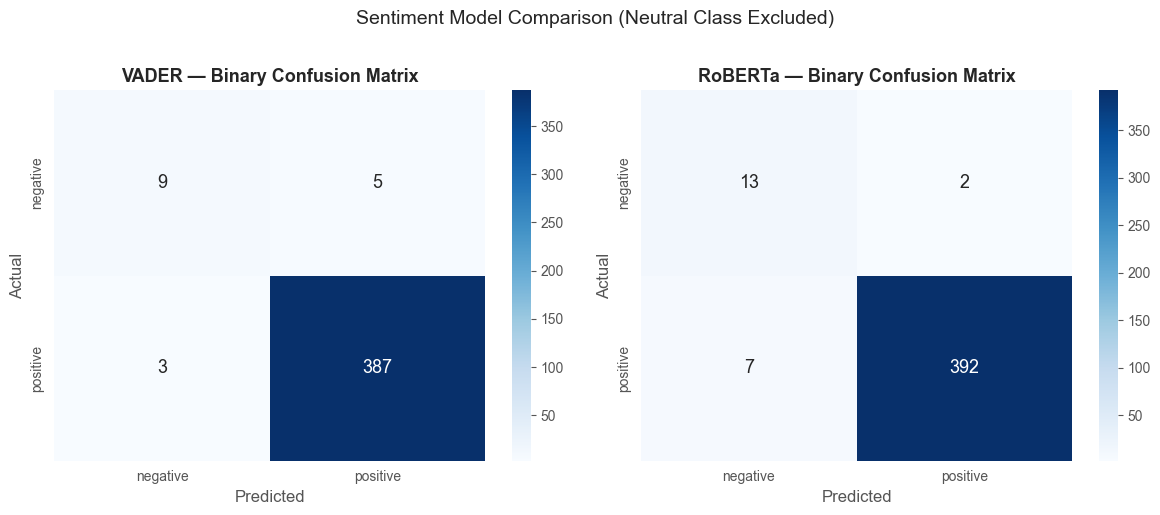

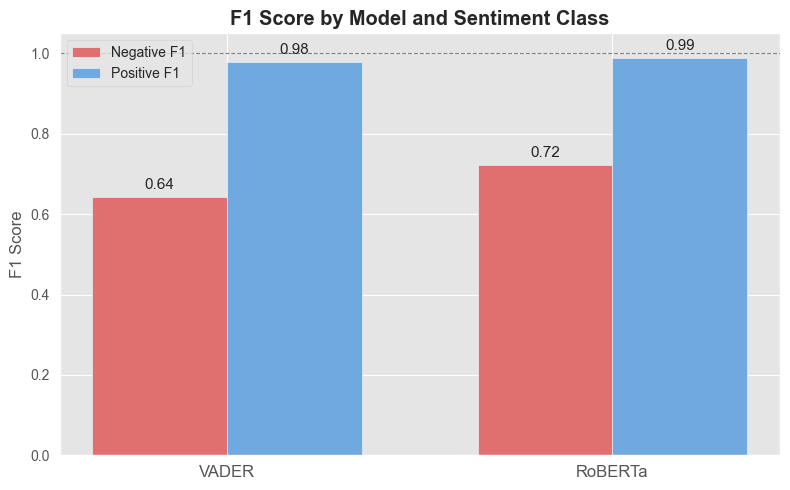

In [18]:
# ── Drop neutral, binary evaluation ──────────────────────────────────────────
binary_df = sentiment_df[sentiment_df['true_label'] != 'neutral'].copy()

print("VADER Binary Report")
print(classification_report(
    binary_df['true_label'],
    binary_df['vaders_label'],
    labels=['negative', 'positive'],
    zero_division=0
))

print("RoBERTa Binary Report")
print(classification_report(
    binary_df['true_label'],
    binary_df['roberta_label'],
    labels=['negative', 'positive'],
    zero_division=0
))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
binary_labels = ['negative', 'positive']

for ax, pred_col, title in zip(
    axes,
    ['vaders_label', 'roberta_label'],
    ['VADER', 'RoBERTa']
):
    cm = confusion_matrix(
        binary_df['true_label'],
        binary_df[pred_col],
        labels=binary_labels
    )
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=binary_labels,
        yticklabels=binary_labels,
        ax=ax,
        annot_kws={"size": 13}
    )
    ax.set_title(f'{title} — Binary Confusion Matrix', fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Sentiment Model Comparison (Neutral Class Excluded)',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


models = ['VADER', 'RoBERTa']

f1_negative = [
    f1_score(binary_df['true_label'], binary_df['vaders_label'],  labels=['negative', 'positive'], average=None, zero_division=0)[0],
    f1_score(binary_df['true_label'], binary_df['roberta_label'], labels=['negative', 'positive'], average=None, zero_division=0)[0],
]
f1_positive = [
    f1_score(binary_df['true_label'], binary_df['vaders_label'],  labels=['negative', 'positive'], average=None, zero_division=0)[1],
    f1_score(binary_df['true_label'], binary_df['roberta_label'], labels=['negative', 'positive'], average=None, zero_division=0)[1],
]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, f1_negative, width, label='Negative F1', color='#e07070')
ax.bar(x + width/2, f1_positive, width, label='Positive F1', color='#70a8e0')
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=12)
ax.set_ylabel('F1 Score')
ax.set_title('F1 Score by Model and Sentiment Class', fontweight='bold')
ax.set_ylim(0, 1.05)
ax.legend()
ax.axhline(y=1.0, color='gray', linestyle='--', linewidth=0.8)

for i, v in enumerate(f1_negative):
    ax.text(i - width/2, v + 0.02, f'{v:.2f}', ha='center', fontsize=11)
for i, v in enumerate(f1_positive):
    ax.text(i + width/2, v + 0.02, f'{v:.2f}', ha='center', fontsize=11)

plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'VADERS Compound Score by Star Reviews')

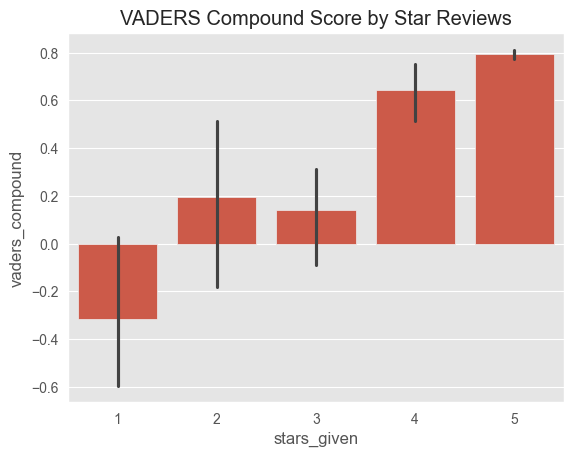

In [19]:
ax = sns.barplot(data=vaders, x="stars_given", y="vaders_compound")
ax.set_title("VADERS Compound Score by Star Reviews")

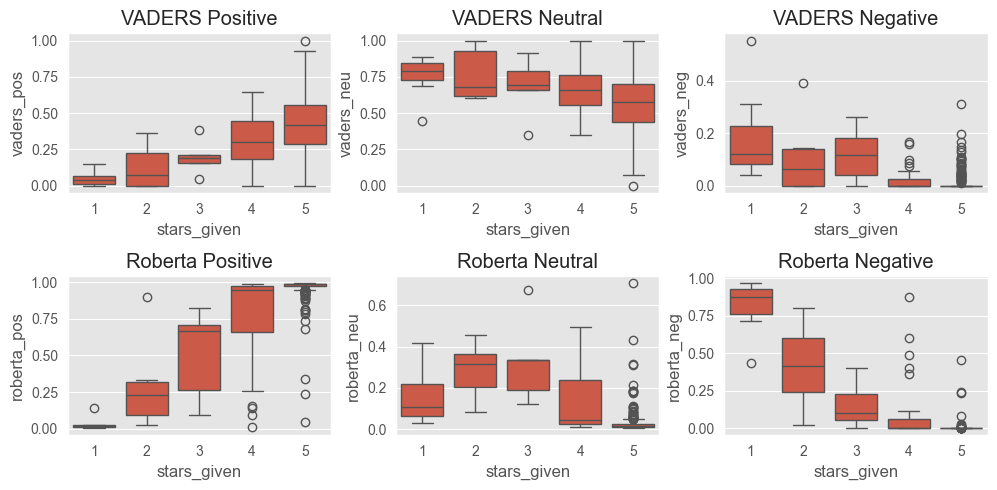

In [20]:
fig, axs = plt.subplots(2, 3, figsize=(10, 5))
sns.boxplot(data=sentiment_df, x="stars_given", y="vaders_pos", ax=axs[0, 0])
sns.boxplot(data=sentiment_df, x="stars_given", y="vaders_neu", ax=axs[0, 1])
sns.boxplot(data=sentiment_df, x="stars_given", y="vaders_neg", ax=axs[0, 2])
axs[0, 0].set_title("VADERS Positive")
axs[0, 1].set_title("VADERS Neutral")
axs[0, 2].set_title("VADERS Negative")
sns.boxplot(data=sentiment_df, x="stars_given", y="roberta_pos", ax=axs[1, 0])
sns.boxplot(data=sentiment_df, x="stars_given", y="roberta_neu", ax=axs[1, 1])
sns.boxplot(data=sentiment_df, x="stars_given", y="roberta_neg", ax=axs[1, 2])
axs[1, 0].set_title("Roberta Positive")
axs[1, 1].set_title("Roberta Neutral")
axs[1, 2].set_title("Roberta Negative")
plt.tight_layout()
plt.show()

<Axes: xlabel='stars_given', ylabel='roberta_compound'>

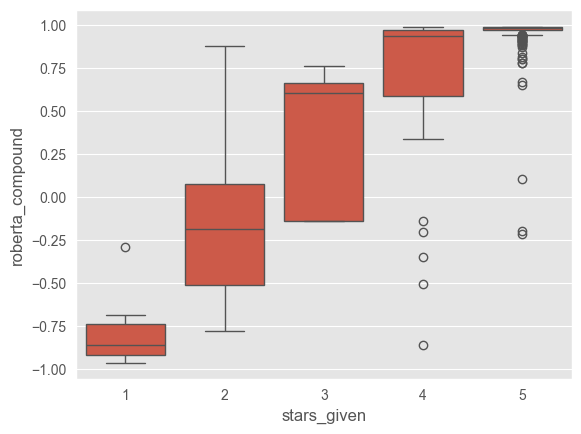

In [21]:
sns.boxplot(
    data=sentiment_df,
    x="stars_given",
    y="roberta_compound"
)

<Axes: xlabel='stars_given', ylabel='vaders_compound'>

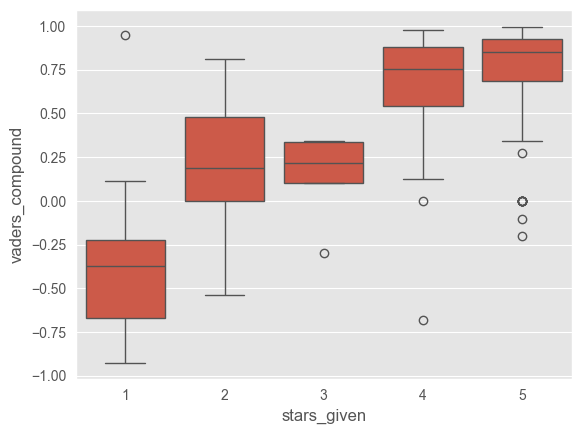

In [22]:
sns.boxplot(
    data=sentiment_df,
    x="stars_given",
    y="vaders_compound"
)

### Sentiment Analysis Results

Both sentiment models demonstrated a relationship between sentiment scores and customer ratings. However, the RoBERTa transformer model appears much more discriminative, creating greater separation between rating categories than VADER. Positive sentiment scores increased consistently from one-star to five-star reviews, while negative sentiment scores decreased. In contrast, VADER classified a large proportion of review text as neutral regardless of rating level, most likely due to the limitations of lexicon-based sentiment analysis approaches. These findings are consistent with the higher F1 score observed for RoBERTa and suggest that contextual transformer-based models capture review sentiment more effectively than lexicon-based approaches.

The most interesting find is the variance in RoBERTa's two-star reviews, which appear very spread in their sentiment intensity. This may suggest that many two-star reviews contain positive language, but the review is dominated by one operational issue.

## Topic Modeling with BERTopic

In [23]:
from bertopic import BERTopic
from bertopic.vectorizers import ClassTfidfTransformer
from sklearn.feature_extraction.text import CountVectorizer

docs = sentiment_df['full_clean_review'].tolist()

# our vectorizor will remove common english stopwords, capture words in at least two reviews, and capture one and two word phrases
vectorizer = CountVectorizer(
    stop_words='english',
    min_df=2,
    ngram_range=(1, 2),
)

ctfidf = ClassTfidfTransformer(reduce_frequent_words=True)

topic_model = BERTopic(
    vectorizer_model=vectorizer,
    ctfidf_model=ctfidf,
    language='english',
    calculate_probabilities=True,
    verbose=True,
    nr_topics='auto',
    min_topic_size=5
)

topics, probs = topic_model.fit_transform(docs)
sentiment_df['topic'] = topics
sentiment_df['topic_prob'] = probs.max(axis=1)

topic_info = topic_model.get_topic_info()
topic_info

2026-06-23 13:45:16,973 - BERTopic - Embedding - Transforming documents to embeddings.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/14 [00:00<?, ?it/s]

2026-06-23 13:45:21,949 - BERTopic - Embedding - Completed ✓
2026-06-23 13:45:21,950 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-06-23 13:45:35,762 - BERTopic - Dimensionality - Completed ✓
2026-06-23 13:45:35,764 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-06-23 13:45:35,844 - BERTopic - Cluster - Completed ✓
2026-06-23 13:45:35,846 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-06-23 13:45:35,903 - BERTopic - Representation - Completed ✓
2026-06-23 13:45:35,904 - BERTopic - Topic reduction - Reducing number of topics
2026-06-23 13:45:35,919 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-06-23 13:45:35,974 - BERTopic - Representation - Completed ✓
2026-06-23 13:45:35,976 - BERTopic - Topic reduction - Reduced number of topics from 19 to 19


,Topic,Count,Name,Representation,Representative_Docs
0,-1,121,-1_parking_years_sure_fun,"[parking, years, sure, fun, really, years ago,...",[exceptional my husband and i were in town fro...
1,0,50,0_beautiful theater_theater beautiful_beautifu...,"[beautiful theater, theater beautiful, beautif...",[wonderful live professional theater group per...
2,1,34,1_bad seat_seat_seat house_bad,"[bad seat, seat, seat house, bad, house, seats...",[get there a little early so you can look arou...
3,2,23,2_funny_wonderful time_family friendly_great s...,"[funny, wonderful time, family friendly, great...",[just went to the ozark mountain daredevils sh...
4,3,22,3_actors_authentic_cheeseheads_hilarious,"[actors, authentic, cheeseheads, hilarious, do...",[here for ryans pub trivia night with doug man...
5,4,21,4_county_door_door county_county great,"[county, door, door county, county great, trip...",[i saw last nights performance of little women...
6,5,20,5_drinks_friendly staff_friendly_staff,"[drinks, friendly staff, friendly, staff, nice...",[older place nice employees small venue good a...
7,6,18,6_northern sky_northern_sky_state park,"[northern sky, northern, sky, state park, stat...",[we love northern sky theater we see their per...
8,7,17,7_meyer_meyer theater_helpful_feels,"[meyer, meyer theater, helpful, feels, things,...",[hi just wanted to let you know that we have b...
9,8,14,8_frank_let frank_let_franks,"[frank, let frank, let, franks, based, fun ent...",[really enjoyed the let me be frank show fun v...


#### Topic Overview and Topic-Sentiment Analysis

Topic -1 is BERTopic's "outlier" bucket - reviews that didn't fit any topic cleanly.

0: Theater Atmosphere <br>
1: Acting & Performance <br>
2: Door County Tourism <br>
3: General Enjoyment <br>
4: Seating Complaints <br>
5: Staff & Drinks <br>
6: Meyer Theater <br>
7: Northern Peninsula Tourism <br>
8: Frank Productions <br>
9: Seating & Acoustics <br>
10: Grounds & Outdoor <br>
11: Venue & Facilities <br>
12: Bucket List Experience <br>
13: Concert Experience <br>
14: Christmas/ABBA Show <br>
15: Performer Talent <br>
16: Family Entertainment <br>
17: Evening Entertainment <br>
18: Daredevils Show

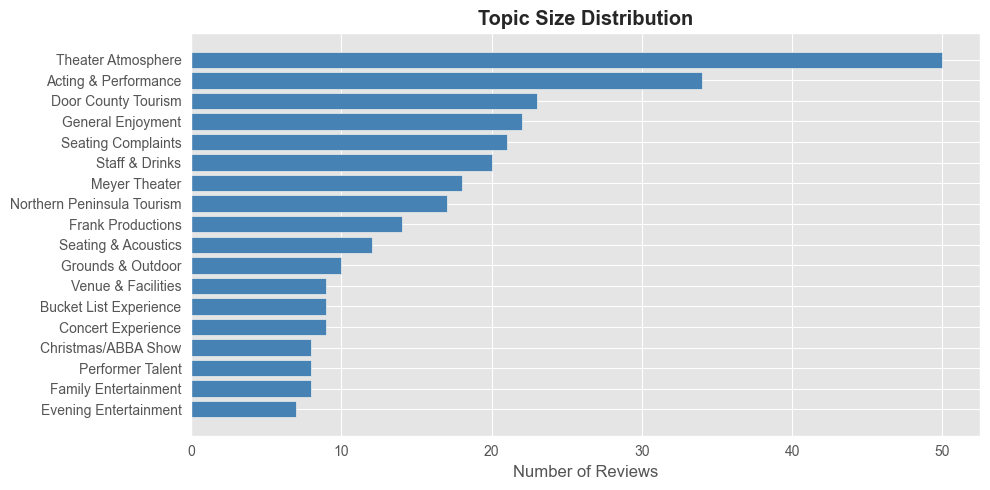

In [24]:
topic_label_map = {
    13: "Concert Experience",
    17: "Evening Entertainment",
    7:  "Northern Peninsula Tourism",
    16: "Family Entertainment",
    11: "Venue & Facilities",
    3:  "General Enjoyment",
    6:  "Meyer Theater",
    1:  "Acting & Performance",
    8:  "Frank Productions",
    12: "Bucket List Experience",
    15: "Performer Talent",
    9:  "Seating & Acoustics",
    18: "Daredevils Show",
    2:  "Door County Tourism",
    0:  "Theater Atmosphere",
    5:  "Staff & Drinks",
    10: "Grounds & Outdoor",
    4:  "Seating Complaints",
    14: "Christmas/ABBA Show",
    -1: "Outlier"
}

topic_info['Name'] = topic_info['Topic'].map(topic_label_map)
sentiment_df['topic_name'] = sentiment_df['topic'].map(topic_label_map)

topic_sizes = topic_info[topic_info['Topic'] != -1].copy()
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(
    topic_sizes['Name'].astype(str),
    topic_sizes['Count'],
    color='steelblue'
)
ax.set_xlabel('Number of Reviews')
ax.set_title('Topic Size Distribution', fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [43]:
prob_threshold = 0.05

def get_multi_labels(prob_row, threshold=prob_threshold):
    labels_mul = [
        (i_, topic_label_map[i_])
        for i_, p in enumerate(prob_row)
        if p >= threshold and i_ in topic_label_map
    ]
    return labels_mul if labels_mul else [(sentiment_df['topic'].iloc[0], 'Outlier')]

sentiment_df['multi_topics'] = [get_multi_labels(row) for row in probs]

sentiment_df['num_topics'] = sentiment_df['multi_topics'].apply(len)
print(sentiment_df['num_topics'].value_counts().sort_index())

num_topics
1    261
2     72
3     35
4     33
5     16
6      3
Name: count, dtype: int64


In [44]:
exploded = sentiment_df[sentiment_df['topic'] != 1].explode('multi_topics')
exploded['topic_num'] = exploded['multi_topics'].apply(lambda l: l[0])
exploded['topic_name'] = exploded['multi_topics'].apply(lambda m: m[1])

topic_sentiment_multi = (
    exploded
    .groupby('topic_name')
    .agg(
        review_count=('topic_name', 'count'),
        avg_stars=('stars_given', 'mean'),
        avg_roberta_compound=('roberta_compound', 'mean'),
        pct_negative=('true_label', lambda a: (a == 'negative').mean() * 100)
    )
    .reset_index()
    .sort_values('avg_stars', ascending=False)
)

topic_sentiment_multi

,topic_name,review_count,avg_stars,avg_roberta_compound,pct_negative
5,Evening Entertainment,18,5.000000,0.955405,0.000000
13,Performer Talent,17,5.000000,0.954912,0.000000
10,Meyer Theater,51,4.960784,0.948275,0.000000
11,Northern Peninsula Tourism,17,4.941176,0.908550,0.000000
4,Door County Tourism,26,4.923077,0.900912,0.000000
7,Frank Productions,12,4.916667,0.979919,0.000000
18,Venue & Facilities,40,4.900000,0.934534,0.000000
15,Seating Complaints,37,4.891892,0.925940,2.702703
6,Family Entertainment,16,4.875000,0.974690,0.000000
12,Outlier,53,4.830189,0.848627,3.773585


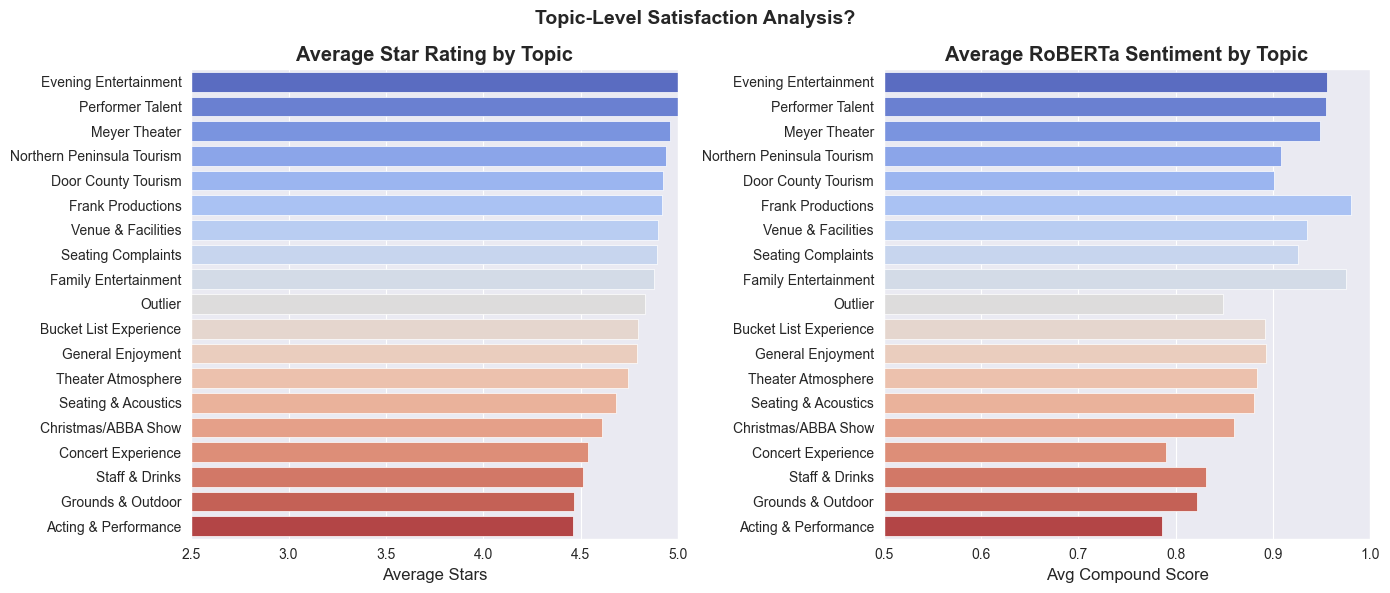

In [63]:
sfig, axes = plt.subplots(1, 2, figsize=(14, 6))

# average stars by topic
sns.barplot(
    data=topic_sentiment_multi.sort_values("avg_stars", ascending=False),
    x='avg_stars',
    y='topic_name',
    hue='topic_name',
    palette='coolwarm',
    legend=False,
    ax=axes[0]
)
axes[0].set_title('Average Star Rating by Topic', fontweight='bold')
axes[0].set_xlabel('Average Stars')
axes[0].set_ylabel('')
axes[0].set_xlim(2.5, 5.0)


# average RoBERTa compound score by topic
sns.barplot(
    data=topic_sentiment_multi.sort_values("avg_stars", ascending=False),
    x='avg_roberta_compound',
    y='topic_name',
    palette='coolwarm',
    ax=axes[1]
)
axes[1].set_title('Average RoBERTa Sentiment by Topic', fontweight='bold')
axes[1].set_xlabel('Avg Compound Score')
axes[1].set_ylabel('')
axes[1].axvline(x=0, color='gray', linestyle='--', linewidth=1)
axes[1].set_xlim(0.5, 1)


plt.suptitle('Topic-Level Satisfaction Analysis?', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

topic_category
Operational        268
General            181
Performance        154
Tourism Context     87
Name: count, dtype: int64


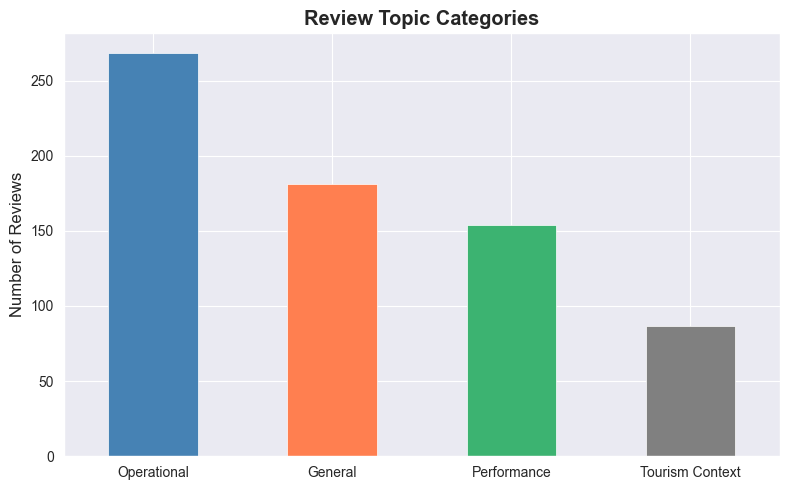

,topic_category,avg_stars,avg_sentiment,count
0,General,4.828729,0.910922,181
1,Operational,4.705224,0.869483,268
2,Performance,4.681818,0.862283,154
3,Tourism Context,4.862069,0.897719,87


In [65]:
performance_topics = [13, 17, 16, 1, 15, 18, 14]
tourism_topics     = [2, 7, 12]
operational_topics = [9, 4, 5, 10, 11]

def categorize_topic(t_):
    if t_ in performance_topics:
        return 'Performance'
    elif t_ in tourism_topics:
        return 'Tourism Context'
    elif t_ in operational_topics:
        return 'Operational'
    else:
        return 'General'

exploded['topic_category'] = exploded['topic_num'].apply(categorize_topic)

cat_counts = exploded['topic_category'].value_counts()
print(cat_counts)

fig, ax = plt.subplots(figsize=(8, 5))
cat_counts.plot(kind='bar', ax=ax, color=['steelblue', 'coral', 'mediumseagreen', 'gray'])
ax.set_title('Review Topic Categories', fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Number of Reviews')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

cat_sentiment = (
    exploded
    .groupby('topic_category')
    .agg(
        avg_stars=('stars_given', 'mean'),
        avg_sentiment=('roberta_compound', 'mean'),
        count=('topic_category', 'count')
    )
    .reset_index()
)
cat_sentiment

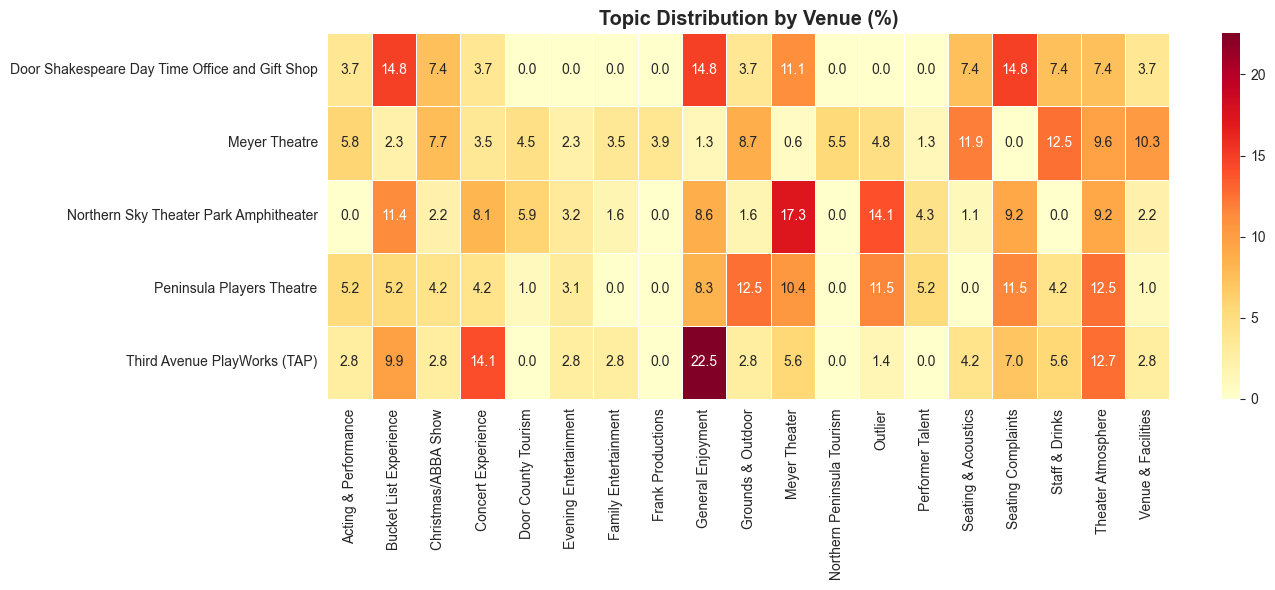

In [67]:
# venue topic distribution
# Answers: do different theaters attract reviews about different topics?

venue_topic = (
    exploded
    .groupby(['venue_name', 'topic_name'])
    .size()
    .reset_index(name='count')
)

venue_topic['pct'] = venue_topic.groupby('venue_name')['count'].transform(
    lambda b: b / b.sum() * 100
)

pivot = venue_topic.pivot(index='venue_name', columns='topic_name', values='pct').fillna(0)

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(
    pivot,
    annot=True,
    fmt='.1f',
    cmap='YlOrRd',
    ax=ax,
    linewidths=0.5
)
ax.set_title('Topic Distribution by Venue (%)', fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

## Topic Modeling Results

---

BERTopic surfaced 19 distinct audience perception themes across 290 reviews, with 130 falling into a miscellaneous outlier bucket and not clustering cleanly. Topics were manually labeled and grouped into four categories: `Performance`, `Operational`, `Tourism Context`, and `General`.

#### What Audiences Talk About
`Performance` and `General` topics accounted for the largest share of reviews, suggesting that audiences primarily engage with the artistic experience rather than logistics. `Tourism Context` topics were the smallest category but had the highest average sentiment (avg RoBERTa compound: 0.94), indicating that when patrons frame their visit in the context of a Door County trip, they are overwhelmingly positive.

#### What Drives Dissatisfaction
`Operational` topics had the lowest average star rating (4.51) and lowest average sentiment (0.78) of any category, noticeably below the dataset average. One topic stood out as a clear pain point:
- **Seating Complaints** averaged 3.95 stars with 26% negative reviews, the highest negative rate of any topic

`Seating Complaints` appeared across every venue, suggesting this is a systemic issue rather than isolated to one organization. The complaint language centered on ticket purchasing confusion, sightline issues, and accessibility.

#### What Audiences Love
Topics with no negative reviews and perfect or near-perfect average star ratings included `Concert Experience`, `Evening Entertainment`, `Northern Peninsula Tourism`, `Family Entertainment`, and `Venue & Facilities`. `Acting & Performance` had the highest RoBERTa compound score of any topic (0.97), indicating that audiences respond most positively to the performances themselves.

#### Venue Differences
The venue-topic heatmap revealed meaningful differences in what audiences discuss across organizations:
- **Door Shakespeare** reviews concentrated on `Bucket List Experience` (14.8&), `General Enjoyment` (14.8%), and `Seating Complaints` (14.8%), highlighting how the performances are loved by tourists and locals alike but notable friction with seating
- **Meyer Theatre** was the most evenly distributed venue, with `Staff and Drinks` (12.5%) and `Venue & Facilities` (10.3%) leading slightly, reflecting a broad audience engaging with multiple aspects of the experience
- **Northern Sky Theater** was defined by `Northern Peninsula Tourism` (17.3%) and `Performer Talent` (14.1%), consistent with its outdoor amphitheater setting where the surrounding environment and performers are central to the experience
- **Peninsula PLayers Theater** had strong `Grounds & Outdoor` (12.5%) and `Performer Talent` (11.5%) presence. Audiences notice both the physical setting and the quality of performance
- **Third Avenue PlayWorks (TAP)** was dominated by `General Enjoyment` (22.5%) by a wide margin, the highest single-topic concentration of any venue, with `Concert Experience` (14.1%) providing additional volume

## Conclusions

This project applied a dual-model NLP sentiment pipeline and BERTopic topic modeling to 420 Google reviews across five rural nonprofit performing arts venues in Door County, Wisconsin, a tourism-driven county. The goal is to understand what factors most influence customer satisfaction at these types of organizations.

### Sentiment Analysis
Both VADER and RoBERTa successfully captured the overwhelmingly positive sentiment of the dataset, consistent with the 88.5% five-star rating distribution. However, the ratings imbalance (96% positive reviews) means overall accuracy is a misleading metric. Performance in the minority negative class is more meaningful as positive could be a default for this specific industry. On this measure, RoBERTa outperformed VADER with a negative-class F1 of 0.72 vs. 0.64, driven by its ability to understand context and tone rather than relying on lexicon matching. For future sentiment work on similarly skewed datasets, transformer-based models are recommended over lexicon-based approaches.

A notable finding was the high variance in RoBERTa sentiment scores for two-star reviews, suggesting these reviews frequently contain positive language dominated by a single operational complaint. This pattern is consistent with the topic modeling results, which identified seating and ticketing as the primary sources of dissatisfaction.

### Topic Modeling
BERTopic surfaced 19 distinct audience perception themes. The clearest finding is the gap between operational and non-operational topics: operational topics averaged 4.51 stars and a RoBERTa compound score of 0.78, noticeably below performance topics (4.81 stars, 0.91 compound) and tourism context topics (4.90 stars, 0.94 compound). Audiences at rural performing arts venues are highly satisfied with the artistic experience itself, whereas dissatisfaction is almost entirely driven by operational issues.

The two lowest-rated topics were Seating Complaints (3.95 avg stars, 26% negative reviews) and Christmas/ABBA Show (3.75 avg stars, 25% negative reviews). Seating complaints appeared across every venue, indicating a systemic issue rather than an isolated one. Review content in this cluster centered on ticket purchasing confusion and sightline issues.

### Venue-Level Insights
The venue-topic heatmap revealed that different organizations attract reviews about meaningfully different aspects of the experience. Northern Sky Theater Park Amphitheater reviews were defined by the outdoor environment and performer talent, reflecting its unique physical setting. Third Avenue PlayWorks (TAP) showed the highest General Enjoyment concentration of any venue (22.5%), suggesting broad satisfaction without strong association with any specific operational or artistic theme. Door Shakespeare had a notable 14.8% concentration in Seating Complaints — the highest of any venue — pointing to a specific area for improvement.

### Recommendations
Based on the analysis, three actionable recommendations emerge for rural nonprofit performing arts organizations:

1. **Streamline ticket purchasing and seating communication.** Seating complaints were the single largest driver of negative reviews across all venues, with complaint language centering on purchasing confusion and sightline clarity. Improving pre-visit communication around seating and simplifying the online ticketing experience would directly address the most common source of dissatisfaction.

2. **Leverage the tourism context.** Tourism-framed reviews had the highest average sentiment of any category. Organizations should lean into their Door County setting in marketing. Audiences who frame their visit as part of a broader regional trip are the most satisfied and most likely to leave positive reviews.

3. **Monitor specific show sentiment separately.** The Christmas/ABBA Show cluster had disproportionately negative sentiment relative to other programming. Tracking sentiment at the individual show level rather than aggregating across all productions would allow organizations to identify underperforming programming earlier.

### Limitations
31% of reviews fell into BERTopic's outlier bucket and were excluded from topic analysis, primarily due to insufficient semantic content in short reviews. The dataset is also inherently skewed. Google reviewers self-select, and dissatisfied patrons may be less likely to leave reviews at all, meaning true dissatisfaction rates are likely higher than what this analysis captures. Finally, while multi-label topic probabilities were used to improve assignment for longer reviews, short single-sentiment reviews will continue to resist clean topic assignment without sentence-level modeling.